In [50]:
# =========================
# Cell 0: imports & config (velocity curves)
# =========================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from matplotlib.lines import Line2D

repo_root = Path("/Users/toddywang/Documents/VsCodeProjects/xmltoexp")
data_root = repo_root / "MazurkaBL-master"
beat_dyn_dir = data_root / "beat_dyn"
beat_time_dir = data_root / "beat_time"

mazurka_id = "M06-1"
beat_time_file = beat_dyn_dir / f"{mazurka_id}beat_dynNORM.csv"

print("beat_dyn_file:", beat_time_file)
assert beat_time_file.exists(), f"File not found: {beat_time_file}"

# =========================
# Cell 1: load + velocity curves
# =========================
def load_beat_time(file_path: Path):
    df = pd.read_csv(file_path)
    meta_cols = {"Unnamed: 0", "measure_number", "beat_number"}
    performer_cols = [c for c in df.columns if c not in meta_cols]
    beat_index = np.arange(len(df), dtype=int)
    return df, performer_cols, beat_index

def compute_velocity_curves(df, performer_cols, smooth_window=1, dyn_range=(0.0, 1.0), clip_max=1.0):
    dyn_arrays = {}
    lo, hi = dyn_range

    for col in performer_cols:
        vals = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
        s = pd.Series(vals)
        s = s.where((s >= lo) & (s <= hi))
        s = s.interpolate("linear", limit_direction="both")
        s = s.rolling(window=smooth_window, center=True, min_periods=1).mean()
        s = s.clip(lower=lo, upper=clip_max)
        dyn_arrays[col] = s.to_numpy()

    return dyn_arrays

df_bt, performer_cols, beat_index = load_beat_time(beat_time_file)
velocity_arrays = compute_velocity_curves(df_bt, performer_cols, smooth_window=3)

print("beats:", len(beat_index))
print("performers:", len(velocity_arrays))


beat_dyn_file: /Users/toddywang/Documents/VsCodeProjects/xmltoexp/MazurkaBL-master/beat_dyn/M06-1beat_dynNORM.csv
beats: 337
performers: 34


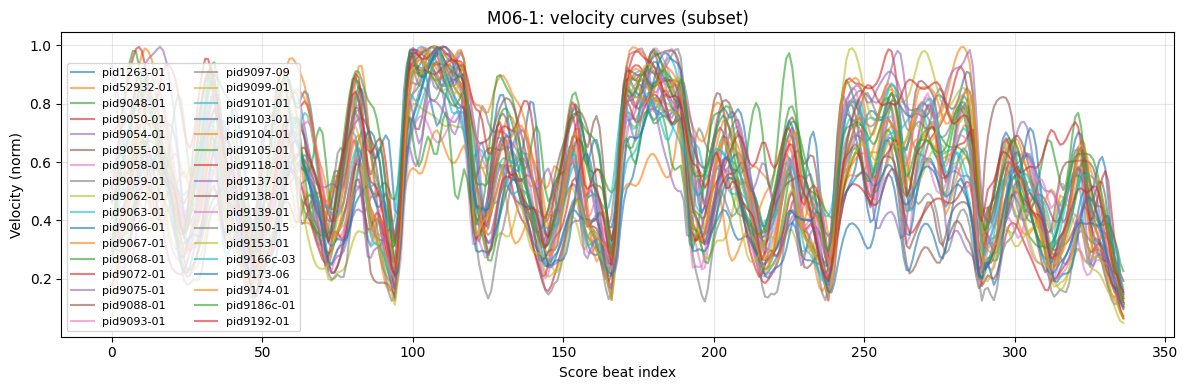

In [51]:
# =========================
# Cell 2: overlay plot (optional)
# =========================
def plot_overlay_velocitys(velocity_arrays, n=5, max_beats=None, seed=0):
    if not velocity_arrays:
        print("velocity_arrays is empty.")
        return
    names = list(velocity_arrays.keys())
    if n is not None and n < len(names):
        rng = np.random.default_rng(seed)
        names = list(rng.choice(names, size=n, replace=False))

    plt.figure(figsize=(12, 4))
    for nm in names:
        curve = velocity_arrays[nm]
        if max_beats is not None:
            curve = curve[:max_beats]
        plt.plot(curve, alpha=0.6, label=nm)
    plt.xlabel("Score beat index")
    plt.ylabel("Velocity (norm)")
    plt.title(f"{mazurka_id}: velocity curves (subset)")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

plot_overlay_velocitys(velocity_arrays, n=34, max_beats=400)

In [52]:
# =========================
# Cell 3: (baseline) single-scale boundary detection (your old method)
# =========================
def group_analysis_new(velocity_curve, ws, plot=False, return_pro=False):
    velocity = np.asarray(velocity_curve, dtype=float)
    n = len(velocity)
    ws = int(ws)
    if ws <= 1 or n == 0:
        return np.array([], dtype=int) if not return_pro else (np.array([], dtype=int), velocity * 0)

    # sliding RMS (zero padding)
    if ws % 2 == 1:
        pad_left = (ws - 1) // 2
        pad_right = ws - 1 - pad_left
    else:
        pad_left = ws // 2
        pad_right = ws - pad_left

    padded = np.pad(velocity, (pad_left, pad_right), mode="constant", constant_values=0.0)
    pro = np.zeros(n, dtype=float)

    for i in range(n):
        window = padded[i:i + ws]
        nonzero = window != 0
        if np.any(nonzero):
            pro[i] = np.sqrt(np.sum(window[nonzero] ** 2) / nonzero.sum())
        else:
            pro[i] = 0.0

    # valleys on pro = peaks on -pro
    min_width = int(np.ceil(ws / 2))
    peaks, _ = find_peaks(-pro, distance=min_width)

    if len(peaks) == 0:
        return np.array([], dtype=int) if not return_pro else (np.array([], dtype=int), pro)

    # refine: local minimum on original velocity
    locs = []
    half = (ws - 1) // 2 if (ws % 2 == 1) else ws // 2
    for p in peaks:
        left = max(0, p - half)
        right = min(n - 1, p + half)
        segment = velocity[left:right + 1]
        if segment.size == 0:
            continue
        locs.append(left + int(np.nanargmin(segment)))

    locs = np.array(sorted(set(locs)), dtype=int)

    if plot:
        fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
        axes[0].plot(pro, label="RMS (pro)")
        axes[0].set_ylabel("RMS")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(velocity, label="velocity")
        axes[1].stem(locs, velocity[locs], linefmt="C1-", markerfmt="C1o", basefmt=" ", label="boundaries")
        axes[1].set_xlabel("Score beat index")
        axes[1].set_ylabel("Velocity")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return (locs, pro) if return_pro else locs

# =========================
# Cell 4: hierarchical boundary detection (thesis/MATLAB-style)
# =========================
def _pad_to_multiple(x, m):
    x = np.asarray(x, dtype=float).reshape(-1)
    pad = (-len(x)) % m
    if pad == 0:
        return x
    return np.concatenate([x, np.zeros(pad, dtype=float)])

def group_analysis_hierarchy(velocity_curve, str_vec, enforce_nested=True):
    """
    Block-hierarchy + trace:
      - Level 1 groups beats into blocks of size str_vec[0]
      - Level i>=2 computes eng2 per block: RMS(norm) - std(norm), finds valleys on eng2
      - Trace from top-level valleys down to beat indices
    Returns:
      results_raw: (L, N) bool, row t means boundaries traced from top=t (1..L)
      level_sets: dict level->np.array beat indices
                 if enforce_nested=True: B_L ⊆ ... ⊆ B_1, with L=coarsest, 1=finest
    """
    velocity = np.asarray(velocity_curve, dtype=float).reshape(-1)
    N = len(velocity)
    str_vec = np.asarray(str_vec, dtype=int).reshape(-1)
    L = len(str_vec)

    if N == 0:
        return np.zeros((L, 0), dtype=bool), {l: np.array([], dtype=int) for l in range(1, L+1)}

    avg = np.nanmean(velocity)
    if not np.isfinite(avg) or avg == 0:
        avg = 1.0

    # 1-indexed containers
    energy  = [None] * (L + 1)
    energy2 = [None] * (L + 1)
    valleys = [None] * (L + 1)

    # Level 1 blocks
    s1 = int(str_vec[0])
    pad_raw  = _pad_to_multiple(velocity, s1)
    pad_norm = _pad_to_multiple(velocity / avg, s1)

    energy[1]  = pad_raw.reshape((s1, -1), order="F")
    energy2[1] = pad_norm.reshape((s1, -1), order="F")

    # Level 1 valleys: beat-level minima on velocity
    v1, _ = find_peaks(-velocity)
    valleys[1] = v1 + 1  # 1-based

    # Higher levels
    for i in range(2, L + 1):
        t_eng = energy[i - 1].copy()
        t_eng[t_eng == 0] = np.nan

        t_norm = t_eng / avg
        eng2 = np.sqrt(np.nanmean(t_norm ** 2, axis=0)) - np.nanstd(t_norm, axis=0)

        vi, _ = find_peaks(-eng2)    # valleys on block sequence
        valleys[i] = vi + 1

        si = int(str_vec[i - 1])
        eng2_pad = _pad_to_multiple(eng2, si)

        # store for next trace step
        energy[i]  = _pad_to_multiple(np.sqrt(np.nanmean(t_eng ** 2, axis=0)), si).reshape((si, -1), order="F")
        energy2[i] = eng2_pad.reshape((si, -1), order="F")

    # Trace from each top level to beats
    results_raw = np.zeros((L, N), dtype=bool)

    for top in range(L, 0, -1):
        roots = valleys[top]
        if roots is None or len(roots) == 0:
            continue

        trace = np.zeros((top, len(roots)), dtype=int)
        trace[0, :] = roots  # 1-based

        for rj in range(len(roots)):
            for i in range(2, top + 1):
                lvl = top + 1 - i
                parent_col = trace[i - 2, rj]
                colvec = energy2[lvl][:, parent_col - 1]
                row = int(np.nanargmin(colvec)) + 1
                trace[i - 1, rj] = int(str_vec[lvl - 1]) * (parent_col - 1) + row

        beats_1b = trace[top - 1, :]
        beats_0b = beats_1b - 1
        beats_0b = beats_0b[(beats_0b >= 0) & (beats_0b < N)]
        results_raw[top - 1, beats_0b] = True

    # raw sets
    level_sets = {l: np.where(results_raw[l-1])[0] for l in range(1, L+1)}

    # nested sets: B_l = union_{t=l..L} raw(t)
    if enforce_nested:
        cum = np.zeros(N, dtype=bool)
        nested = {}
        for l in range(L, 0, -1):
            cum |= results_raw[l-1]
            nested[l] = np.where(cum)[0]
        level_sets = nested

    return results_raw, level_sets


In [53]:
# =========================
# Cell 5: visualization (single performer) - clearer legend/levels
# =========================
def plot_hierarchy_on_velocity(velocity_curve, level_sets, title="", max_beats=400):
    velocity = np.asarray(velocity_curve, dtype=float)
    n = min(len(velocity), max_beats)
    velocity = velocity[:n]
    L = max(level_sets.keys())
    y0, y1 = np.nanmin(velocity), np.nanmax(velocity)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(velocity, alpha=0.9, linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel("Score beat index")
    ax.set_ylabel("Velocity (norm)")
    ax.grid(alpha=0.3)

    linestyles = ["-", "--", "-.", ":", (0, (5, 2, 1, 2)), (0, (1, 1))]
    handles = []

    for l in range(L, 0, -1):
        xs = np.asarray(level_sets[l], dtype=int)
        xs = xs[xs < n]
        if xs.size == 0:
            continue

        lw = 0.8 + 1.2 * (l / L)
        alpha = 0.12 + 0.70 * (l / L)
        ls = linestyles[(L - l) % len(linestyles)]

        # coarse levels drawn only in upper region (avoid clutter)
        if l >= L - 1:
            yy0 = y0 + 0.55 * (y1 - y0)
        elif l >= L - 3:
            yy0 = y0 + 0.25 * (y1 - y0)
        else:
            yy0 = y0

        ax.vlines(xs, ymin=yy0, ymax=y1, linewidth=lw, alpha=alpha, linestyles=ls)
        handles.append(Line2D([0], [0], color="C1", lw=lw, alpha=alpha, linestyle=ls, label=f"Level {l}"))

    # legend
    ax.legend(handles=handles, ncol=3, fontsize=9, frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

def plot_hierarchy_raster(level_sets, n_beats, title="", max_beats=400):
    n = min(n_beats, max_beats)
    L = max(level_sets.keys())
    mat = np.zeros((L, n), dtype=float)
    for l in range(1, L+1):
        xs = np.asarray(level_sets[l], dtype=int)
        xs = xs[xs < n]
        mat[l-1, xs] = l / L  # weight: coarse brighter

    # show level L at top for readability
    mat_show = mat[::-1, :]
    ylabels = [f"L{l}" for l in range(L, 0, -1)]

    plt.figure(figsize=(14, 3.8))
    plt.imshow(mat_show, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(L), ylabels)
    plt.xlabel("Score beat index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

n performers: 34
first 10: ['pid1263-01', 'pid52932-01', 'pid9048-01', 'pid9050-01', 'pid9054-01', 'pid9055-01', 'pid9058-01', 'pid9059-01', 'pid9062-01', 'pid9063-01']


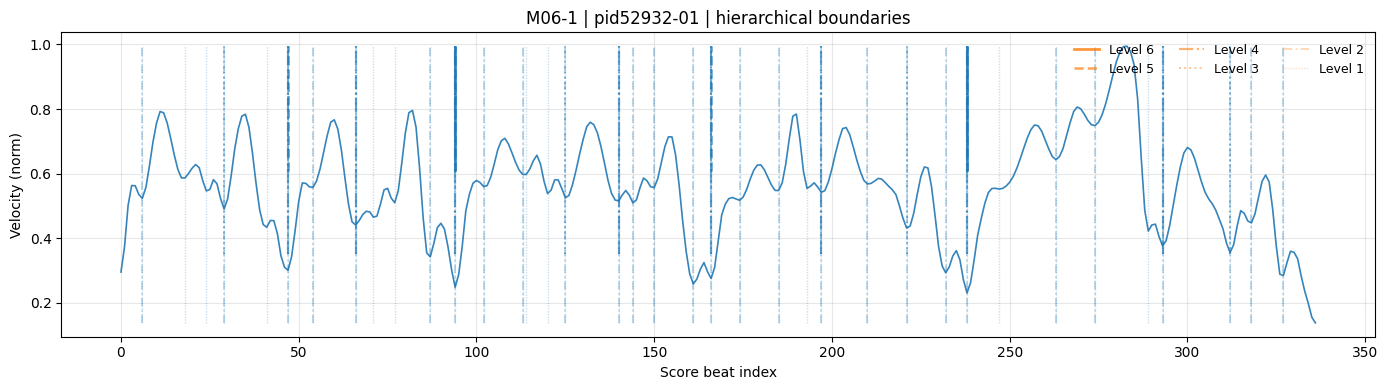

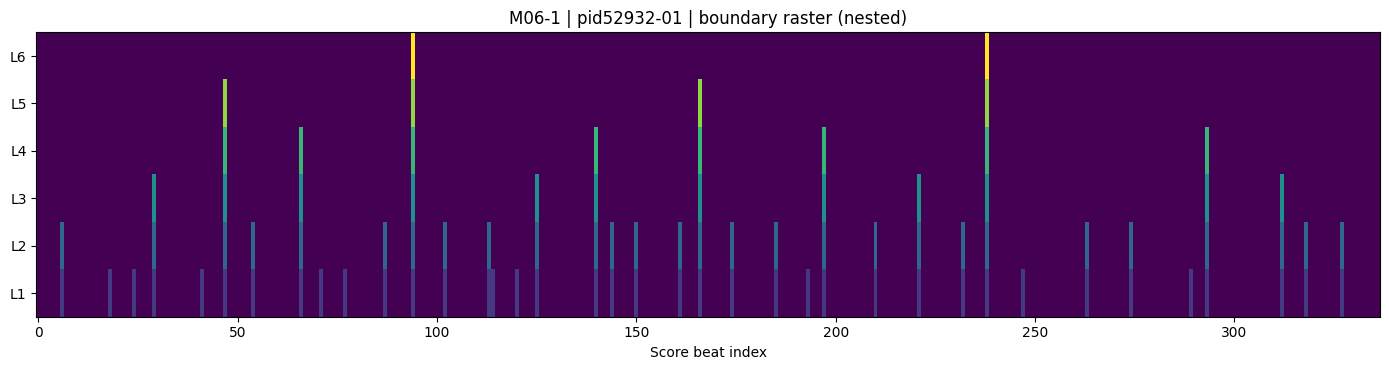

In [54]:
# =========================
# Cell 6: run hierarchy on one performer + plot
# =========================
str_vec = [3,2,2,2,2,2]  # 6 levels

names = list(velocity_arrays.keys())
print("n performers:", len(names))
print("first 10:", names[:10])

one_name = names[1]   # change this index to view a different performer
curve = velocity_arrays[one_name]

results_raw, level_sets = group_analysis_hierarchy(curve, str_vec, enforce_nested=True)

plot_hierarchy_on_velocity(curve, level_sets, title=f"{mazurka_id} | {one_name} | hierarchical boundaries", max_beats=400)
plot_hierarchy_raster(level_sets, n_beats=len(curve), title=f"{mazurka_id} | {one_name} | boundary raster (nested)", max_beats=400)


In [55]:
# =========================
# Cell 7: aggregate across all performers
# =========================
def aggregate_levels_across_performers(velocity_arrays, str_vec, max_beats=None, enforce_nested=True):
    names = list(velocity_arrays.keys())
    n_perf = len(names)
    n_beats = len(next(iter(velocity_arrays.values())))
    if max_beats is not None:
        n_beats = min(n_beats, int(max_beats))
    L = len(str_vec)

    counts = np.zeros((L, n_beats), dtype=int)
    per_perf_levels = {}

    for nm in names:
        curve = velocity_arrays[nm]
        if max_beats is not None:
            curve = curve[:n_beats]
        _, level_sets = group_analysis_hierarchy(curve, str_vec, enforce_nested=enforce_nested)
        per_perf_levels[nm] = level_sets
        for l in range(1, L+1):
            xs = np.asarray(level_sets[l], dtype=int)
            xs = xs[(xs >= 0) & (xs < n_beats)]
            counts[l-1, xs] += 1

    freq = counts / max(n_perf, 1)
    return counts, freq, per_perf_levels

counts, freq, per_perf_levels = aggregate_levels_across_performers(velocity_arrays, str_vec, max_beats=400, enforce_nested=True)
print("aggregate done. freq shape:", freq.shape)




aggregate done. freq shape: (6, 337)


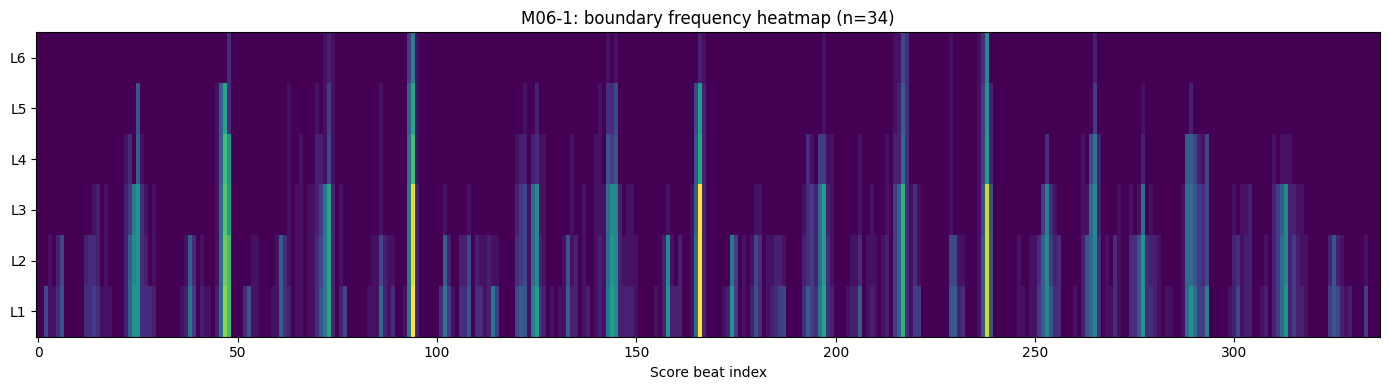

In [56]:
# =========================
# Cell 8: visualize aggregation - heatmap
# =========================
def plot_boundary_heatmap(freq, title="boundary frequency heatmap", show_levels_top_down=True):
    L, N = freq.shape
    mat = freq
    if show_levels_top_down:
        mat = mat[::-1, :]
        ylabels = [f"L{l}" for l in range(L, 0, -1)]
    else:
        ylabels = [f"L{l}" for l in range(1, L+1)]

    plt.figure(figsize=(14, 4))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(L), ylabels)
    plt.xlabel("Score beat index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_boundary_heatmap(freq, title=f"{mazurka_id}: boundary frequency heatmap (n={len(velocity_arrays)})")



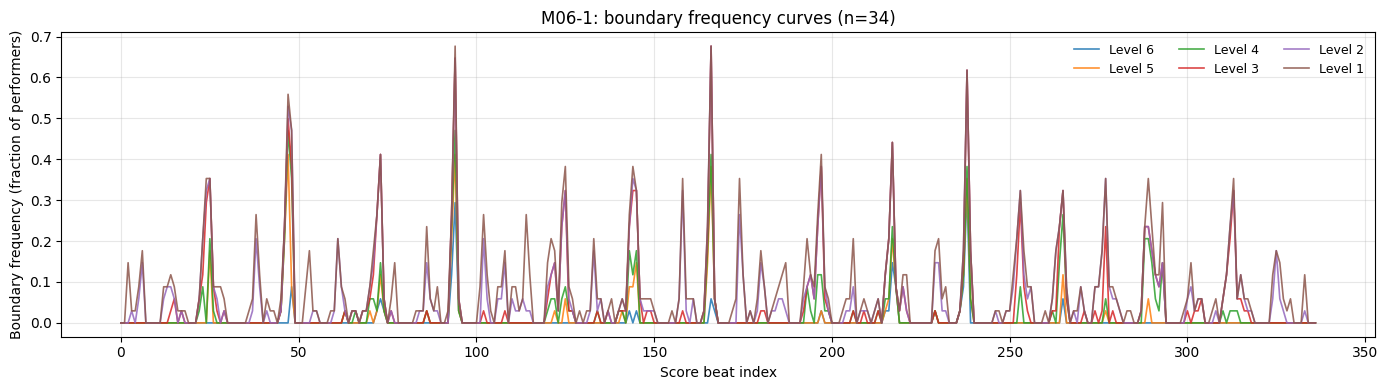

In [57]:
# =========================
# Cell 9: visualize aggregation - per-level frequency curves
# =========================
def plot_level_frequency_curves(freq, title="boundary frequency curves"):
    L, N = freq.shape
    plt.figure(figsize=(14, 4))
    for l in range(L, 0, -1):
        plt.plot(freq[l-1, :], linewidth=1.2, alpha=0.85, label=f"Level {l}")
    plt.xlabel("Score beat index")
    plt.ylabel("Boundary frequency (fraction of performers)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(ncol=3, fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()

plot_level_frequency_curves(freq, title=f"{mazurka_id}: boundary frequency curves (n={len(velocity_arrays)})")


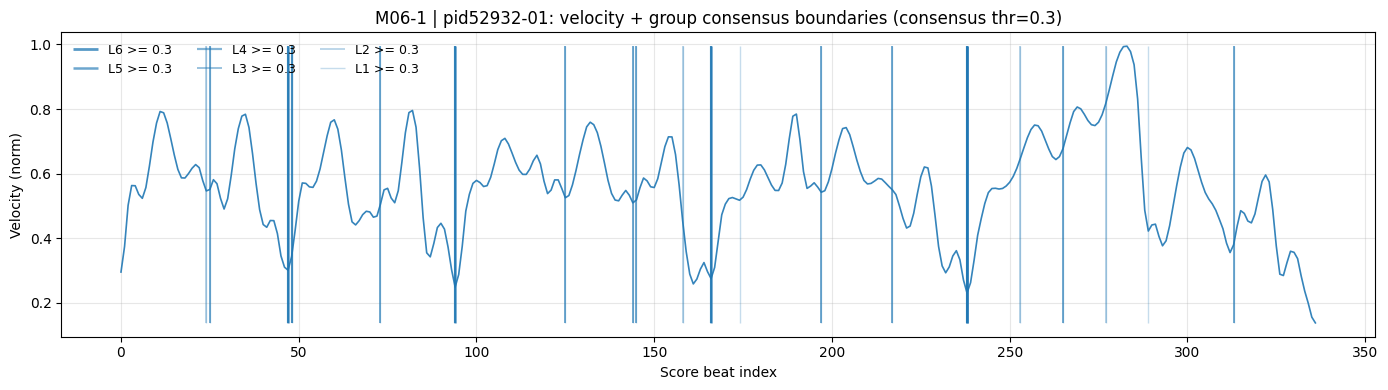

In [58]:
# =========================
# Cell 10: overlay consensus boundaries on one performer's velocity
# =========================
def plot_consensus_on_velocity(velocity_curve, freq, title="", thr=0.3):
    velocity = np.asarray(velocity_curve, dtype=float)
    n = min(len(velocity), freq.shape[1])
    velocity = velocity[:n]

    L = freq.shape[0]
    y0, y1 = np.nanmin(velocity), np.nanmax(velocity)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(velocity, alpha=0.9, linewidth=1.2)
    ax.set_title(title + f" (consensus thr={thr})")
    ax.set_xlabel("Score beat index")
    ax.set_ylabel("Velocity (norm)")
    ax.grid(alpha=0.3)

    for l in range(L, 0, -1):
        xs = np.where(freq[l-1, :n] >= thr)[0]
        if xs.size == 0:
            continue
        lw = 0.8 + 1.2*(l/L)
        alpha = 0.15 + 0.60*(l/L)
        ax.vlines(xs, ymin=y0, ymax=y1, linewidth=lw, alpha=alpha, label=f"L{l} >= {thr}")

    ax.legend(ncol=3, fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()

plot_consensus_on_velocity(
    velocity_arrays[one_name],
    freq,
    title=f"{mazurka_id} | {one_name}: velocity + group consensus boundaries",
    thr=0.3
)

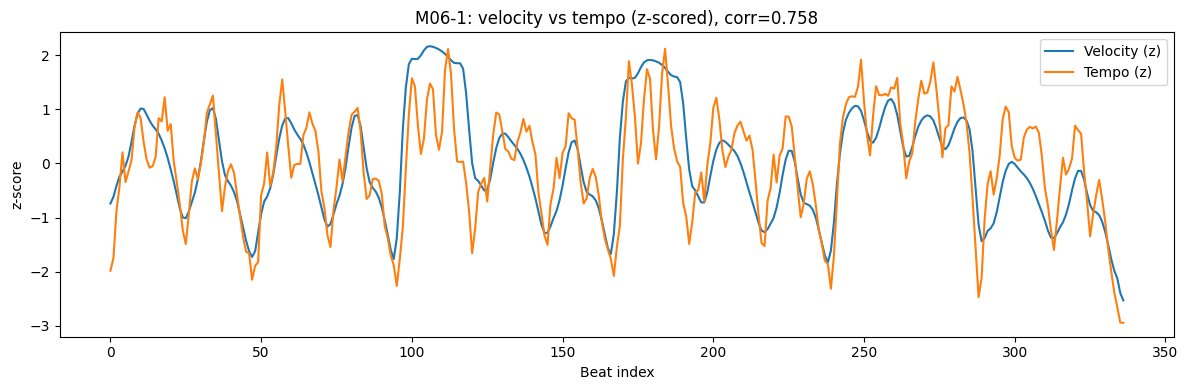

In [59]:
# =========================
# Cell: compare velocity curve vs tempo curve (correlation)
# =========================
def load_mean_velocity_curve(beat_dyn_file, smooth_window=3, clip_max=1.0):
    df = pd.read_csv(beat_dyn_file)
    meta_cols = {"Unnamed: 0", "measure_number", "beat_number"}
    perf_cols = [c for c in df.columns if c not in meta_cols]
    curves = []
    for col in perf_cols:
        vals = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
        s = pd.Series(vals)
        s = s.interpolate("linear", limit_direction="both")
        s = s.rolling(window=smooth_window, center=True, min_periods=1).mean()
        s = s.clip(lower=0.0, upper=clip_max)
        curves.append(s.to_numpy())
    if not curves:
        return None
    min_len = min(len(c) for c in curves)
    curves = [c[:min_len] for c in curves]
    return np.mean(np.stack(curves, axis=0), axis=0)

def load_mean_tempo_curve(beat_time_file, smooth_window=3, dyn_range=(0, 5000), clip_max=600):
    df = pd.read_csv(beat_time_file)
    meta_cols = {"Unnamed: 0", "measure_number", "beat_number"}
    perf_cols = [c for c in df.columns if c not in meta_cols]
    curves = []
    lo, hi = dyn_range
    for col in perf_cols:
        times = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
        dt = np.diff(times, prepend=np.nan)
        tempo = 60.0 / dt
        invalid = (dt <= 0) | (~np.isfinite(tempo))
        tempo[invalid] = np.nan
        s = pd.Series(tempo)
        s = s.where((s > lo) & (s < hi))
        s = s.interpolate("linear", limit_direction="both")
        s = s.rolling(window=smooth_window, center=True, min_periods=1).mean()
        s = s.clip(upper=clip_max)
        curves.append(s.to_numpy())
    if not curves:
        return None
    min_len = min(len(c) for c in curves)
    curves = [c[:min_len] for c in curves]
    return np.mean(np.stack(curves, axis=0), axis=0)

# files
beat_dyn_file = data_root / 'beat_dyn' / f'{mazurka_id}beat_dynNORM.csv'
beat_time_file = data_root / 'beat_time' / f'{mazurka_id}beat_time.csv'

vel_mean = load_mean_velocity_curve(beat_dyn_file, smooth_window=3, clip_max=1.0)
tempo_mean = load_mean_tempo_curve(beat_time_file, smooth_window=3, dyn_range=(0,5000), clip_max=600)

if vel_mean is None or tempo_mean is None:
    print('Missing curves for comparison')
else:
    n = min(len(vel_mean), len(tempo_mean))
    vel = vel_mean[:n]
    tmp = tempo_mean[:n]
    # z-score normalize for fair comparison
    vel_z = (vel - vel.mean()) / (vel.std() + 1e-8)
    tmp_z = (tmp - tmp.mean()) / (tmp.std() + 1e-8)
    corr = float(np.corrcoef(vel_z, tmp_z)[0,1])

    plt.figure(figsize=(12, 4))
    plt.plot(vel_z, label='Velocity (z)')
    plt.plot(tmp_z, label='Tempo (z)')
    plt.title(f'{mazurka_id}: velocity vs tempo (z-scored), corr={corr:.3f}')
    plt.xlabel('Beat index')
    plt.ylabel('z-score')
    plt.legend()
    plt.tight_layout()
    plt.show()
